# Hybryda LSTM + XGBoost — prognoza ceny BTC na horyzoncie +7 dni (168h)

**Dlaczego ten horyzont:** praca *"Forecasting Bitcoin price direction with random forests"*
(ScienceDirect) pokazała, że trafność kierunkowa systematycznie rośnie z horyzontem —
75-80% dla prognozy 5-dniowej, >85% dla 10-20 dni — na **makroekonomicznych** zmiennych
(stopy procentowe, inflacja, VIX, ropa), których jeszcze nie mamy. Zanim dodamy nowe źródła
danych, sprawdzamy najpierw, czy sam dłuższy horyzont (+7 dni zamiast +1h/+24h) poprawia
stosunek sygnał/szum **na już posiadanych cechach** (whale, opcje, wskaźniki techniczne).

## Dwie poprawki wbudowane od razu (na bazie wniosków z +1h i +24h)

**1. Wycentrowanie dryfu.** Przy +24h zobaczyliśmy: dryf treningowy (+0.00115) ≠ dryf testowy
(-0.00030) — model uczył się głównie kierunku rynku z okresu treningowego, nie realnej
zależności od cech. Przy +7 dniach ten efekt będzie jeszcze silniejszy (dłuższy horyzont =
większa kumulacja trendu), więc **od razu** odejmujemy kroczącą 30-dniową średnią zwrotu
przed treningiem.

**2. Zbalansowana architektura.** `LayerNormalization` prowadziła do mode collapse (model
zawsze przewidywał "wzrost", odch. std. predykcji ≈0.00006). Brak normalizacji prowadził do
natychmiastowego przeuczenia. Tu: mniejszy model (`LSTM(16)`) + `recurrent_dropout` +
`kernel_regularizer(l2)` + `clipnorm` — łagodniejsza regularizacja bez całkowitego tłumienia
wariancji predykcji.

## 1. Importy i konfiguracja

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import warnings, io, re
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import tensorflow as tf
from tensorflow.keras import Input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import xgboost as xgb

np.random.seed(42)
tf.random.set_seed(42)

plt.rcParams.update({
    'figure.figsize': (14, 6),
    'figure.dpi': 100,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.fontsize': 10,
})

COLOR_TRUE = '#111111'
COLOR_LSTM = '#1565C0'
COLOR_HYBRID = '#C62828'
COLOR_NAIVE = '#9E9E9E'

OUT_DIR = './data/hourly/processed'
os.makedirs(OUT_DIR, exist_ok=True)

print('Biblioteki wczytane pomyślnie.')
print(f'TensorFlow: {tf.__version__}   XGBoost: {xgb.__version__}')

2026-08-20 12:00:18.935030: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Biblioteki wczytane pomyślnie.
TensorFlow: 2.16.2   XGBoost: 3.2.0


## 2. Wczytanie danych i cel: zwrot za 7 dni, wycentrowany

**Cel: `target_return_7d_fwd_detrended`** = `ln(Close[t+168]/Close[t])` **minus** krocząca
30-dniowa średnia tego zwrotu (licząc wyłącznie z przeszłości, `shift(1)` żeby nie zaglądać
w przyszłość).

In [2]:
HORIZON = 168  # 7 dni w godzinach
DRIFT_WINDOW = 720  # 30 dni w godzinach, do wycentrowania dryfu

CSV_PATH = '/Users/mateuszpuk/Desktop/bitcoin-onchain-analysis/src/hourly/data/hourly/processed/bitcoin_hourly_final.csv'   # <- dostosuj do swojej ścieżki

df = pd.read_csv(CSV_PATH)
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp').drop_duplicates(subset='timestamp').set_index('timestamp')
df = df.interpolate(method='linear', limit_direction='forward').ffill().dropna()

df['target_return_7d_fwd'] = np.log(df['Close'].shift(-HORIZON) / df['Close'])

# Krocząca średnia zwrotu, licząc TYLKO z przeszłości (shift(1) -> nie zawiera bieżącej wartości)
df['rolling_drift'] = df['target_return_7d_fwd'].rolling(DRIFT_WINDOW, min_periods=168).mean().shift(1)
df['target_return_7d_detrended'] = df['target_return_7d_fwd'] - df['rolling_drift']

df = df.dropna(subset=['target_return_7d_fwd', 'rolling_drift', 'target_return_7d_detrended'])

print(f'Zakres dat:      {df.index.min()} → {df.index.max()}')
print(f'Liczba rekordów: {len(df):,}')
print(df[['target_return_7d_fwd', 'rolling_drift', 'target_return_7d_detrended']].describe())

Zakres dat:      2022-05-17 00:00:00 → 2026-08-10 16:00:00
Liczba rekordów: 35,590
       target_return_7d_fwd  rolling_drift  target_return_7d_detrended
count          35590.000000   35590.000000                35590.000000
mean               0.003572       0.003557                    0.000015
std                0.070285       0.033558                    0.068644
min               -0.466973      -0.103639                   -0.400576
25%               -0.031475      -0.014864                   -0.039797
50%                0.003592       0.002719                    0.000398
75%                0.039273       0.022933                    0.038526
max                0.320833       0.099333                    0.304863


## 3. Cechy wejściowe (ten sam zestaw co poprzednio)

In [3]:
FEATURE_COLS = [
    'log_return_1h',
    'log_return_24h',
    'whale_tx_count',
    'rsi_14h',
    'macd_hist',
    'whale_vol_sum_24h',
    'whale_vol_sum_168h',
]
FEATURE_COLS = [c for c in FEATURE_COLS if c in df.columns]
TARGET_COL = 'target_return_7d_detrended'

print(f'Liczba cech wejściowych: {len(FEATURE_COLS)}')
print(FEATURE_COLS)

Liczba cech wejściowych: 7
['log_return_1h', 'log_return_24h', 'whale_tx_count', 'rsi_14h', 'macd_hist', 'whale_vol_sum_24h', 'whale_vol_sum_168h']


## 4. Podział chronologiczny (80/10/10)

In [4]:
TRAIN_FRAC = 0.80
VAL_FRAC   = 0.10

n = len(df)
n_train = int(n * TRAIN_FRAC)
n_val   = int(n * VAL_FRAC)

train_df = df.iloc[:n_train]
val_df   = df.iloc[n_train:n_train + n_val]
test_df  = df.iloc[n_train + n_val:]

print(f'Trening:    {len(train_df):>7,} godzin   ({train_df.index.min()} → {train_df.index.max()})')
print(f'Walidacja:  {len(val_df):>7,} godzin   ({val_df.index.min()} → {val_df.index.max()})')
print(f'Test:       {len(test_df):>7,} godzin   ({test_df.index.min()} → {test_df.index.max()})')

print()
print(f'Średni zwrot 7d w treningu (przed wycentrowaniem): {train_df["target_return_7d_fwd"].mean():.5f}')
print(f'Średni zwrot 7d w teście   (przed wycentrowaniem): {test_df["target_return_7d_fwd"].mean():.5f}')
print(f'Średni zwrot 7d w treningu (PO wycentrowaniu):     {train_df[TARGET_COL].mean():.5f}')
print(f'Średni zwrot 7d w teście   (PO wycentrowaniu):     {test_df[TARGET_COL].mean():.5f}')

Trening:     28,472 godzin   (2022-05-17 00:00:00 → 2025-09-07 05:00:00)
Walidacja:    3,559 godzin   (2025-09-07 06:00:00 → 2026-02-11 22:00:00)
Test:         3,559 godzin   (2026-02-11 23:00:00 → 2026-08-10 16:00:00)

Średni zwrot 7d w treningu (przed wycentrowaniem): 0.00790
Średni zwrot 7d w teście   (przed wycentrowaniem): -0.00333
Średni zwrot 7d w treningu (PO wycentrowaniu):     0.00008
Średni zwrot 7d w teście   (PO wycentrowaniu):     0.00740


## 5. Skalowanie i sekwencje

Okno wejściowe: 24h historii (jak w poprzednich notebookach) → prognoza wycentrowanego zwrotu
za kolejne 7 dni.

In [5]:
WINDOW_LSTM = 24

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_raw = scaler_X.fit_transform(train_df[FEATURE_COLS].values)
X_val_raw   = scaler_X.transform(val_df[FEATURE_COLS].values)
X_test_raw  = scaler_X.transform(test_df[FEATURE_COLS].values)

y_train_raw = scaler_y.fit_transform(train_df[[TARGET_COL]].values)
y_val_raw   = scaler_y.transform(val_df[[TARGET_COL]].values)
y_test_raw  = scaler_y.transform(test_df[[TARGET_COL]].values)

def make_sequences(X, y, window):
    Xs, ys = [], []
    for i in range(window, len(X)):
        Xs.append(X[i - window:i, :])
        ys.append(y[i, 0])
    return np.array(Xs), np.array(ys)

X_tr, y_tr = make_sequences(X_train_raw, y_train_raw, WINDOW_LSTM)
X_va, y_va = make_sequences(X_val_raw,   y_val_raw,   WINDOW_LSTM)
X_te, y_te = make_sequences(X_test_raw,  y_test_raw,  WINDOW_LSTM)

n_features = X_tr.shape[-1]
print(f'Sekwencje: train={X_tr.shape}  val={X_va.shape}  test={X_te.shape}')

# Prawdziwe (nieskalowane, WYCENTROWANE) zwroty
train_return_detrended_true = train_df[TARGET_COL].values[WINDOW_LSTM:]
val_return_detrended_true   = val_df[TARGET_COL].values[WINDOW_LSTM:]
test_return_detrended_true  = test_df[TARGET_COL].values[WINDOW_LSTM:]

# Dryf odpowiadający tym samym wierszom (do odtworzenia pełnego zwrotu i ceny)
train_drift = train_df['rolling_drift'].values[WINDOW_LSTM:]
val_drift   = val_df['rolling_drift'].values[WINDOW_LSTM:]
test_drift  = test_df['rolling_drift'].values[WINDOW_LSTM:]

train_last_close = train_df['Close'].values[WINDOW_LSTM:]
val_last_close   = val_df['Close'].values[WINDOW_LSTM:]
test_last_close  = test_df['Close'].values[WINDOW_LSTM:]

test_return_full_true = test_df['target_return_7d_fwd'].values[WINDOW_LSTM:]  # pełny (niewycentrowany) zwrot
test_price_true = test_last_close * np.exp(test_return_full_true)

Sekwencje: train=(28448, 24, 7)  val=(3535, 24, 7)  test=(3535, 24, 7)


## 6. Etap 1 — LSTM (mniejszy model, łagodniejsza regularizacja)

`LSTM(16)` (znacznie mniejszy niż `K_HIDDEN=64` z artykułu — przy tak słabym sygnale duża
pojemność szkodzi bardziej niż pomaga, jak widzieliśmy przy +24h) z `recurrent_dropout`,
`kernel_regularizer(l2)` i `clipnorm` (przeciw dużym gradientom od nietypowych ruchów cen).

In [6]:
def print_polish_summary(model):
    stream = io.StringIO()
    model.summary(print_fn=lambda x: stream.write(x + '\n'))
    s = stream.getvalue()
    names = {'dense': 'Gęsta', 'dropout': 'Dropout', 'lstm': 'LSTM', 'input': 'Wejście'}
    def shorten(m):
        t = m.group(2).lower()
        return f'{names.get(t, m.group(2)):<{len(m.group(0))}}'
    s = re.sub(r'(\w+)\s*\((\w+)\)', shorten, s)
    for eng, pol in {
        "type         ": "Warstwa (typ)", "Output Shape   ": "Kształt wyjścia",
        "  Param #": "Parametry", "Total params:": "Suma parametrów:        ",
        "Trainable params:": "Parametry trenowalne:   ",
        "Non-trainable params:": "Parametry nietrenowalne:",
    }.items():
        s = s.replace(eng, pol)
    print(s)

K_HIDDEN = 16

inputs = Input(shape=(WINDOW_LSTM, n_features), name='input_layer')
lstm_out = LSTM(
    K_HIDDEN,
    recurrent_dropout=0.2,
    kernel_regularizer=l2(0.001),
    name='lstm_feature_extractor',
)(inputs)
x = Dropout(0.3)(lstm_out)
return_head = Dense(1, kernel_regularizer=l2(0.001), name='return_head')(x)

lstm_model = Model(inputs=inputs, outputs=return_head)
feature_extractor = Model(inputs=inputs, outputs=lstm_out)

optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005, clipnorm=1.0)
lstm_model.compile(optimizer=optimizer, loss='mse')
print_polish_summary(lstm_model)

cb = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1),
]
print('Trening LSTM (Etap 1)...')
hist = lstm_model.fit(
    X_tr, y_tr, validation_data=(X_va, y_va),
    epochs=100, batch_size=64, callbacks=cb, verbose=1, shuffle=True,
)
print('✓ LSTM wytrenowany.')

Model: "functional"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Warstwa (typ)                   ┃ Kształt wyjścia        ┃     Parametry ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ InputLayer                      │ (None, 24, 7)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ LSTM                            │ (None, 16)             │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout                         │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Gęsta                           │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘
 Suma parametrów:         1,553 (6.07 KB)
 Parametry trenowalne:    1,553 (6.07 KB)
 Parametry nietrenowalne: 0 (0.00 B)


Trening LS

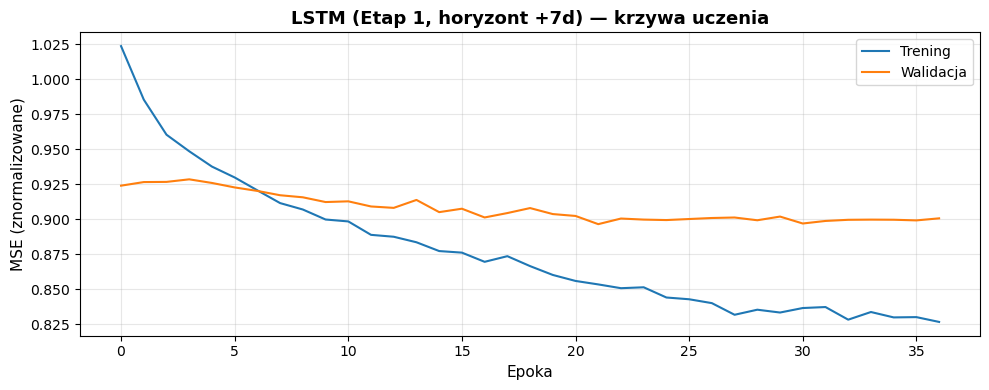

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(hist.history['loss'], label='Trening')
ax.plot(hist.history['val_loss'], label='Walidacja')
ax.set_title('LSTM (Etap 1, horyzont +7d) — krzywa uczenia', fontweight='bold')
ax.set_xlabel('Epoka')
ax.set_ylabel('MSE (znormalizowane)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'hybrid7d_lstm_learning_curve.png'), bbox_inches='tight', dpi=130)
plt.show()

## 7. Ekstrakcja wektora `z`

In [8]:
z_train = feature_extractor.predict(X_tr, verbose=0)
z_val   = feature_extractor.predict(X_va, verbose=0)
z_test  = feature_extractor.predict(X_te, verbose=0)

print(f'Wektory cech (z): train={z_train.shape}  val={z_val.shape}  test={z_test.shape}')

Wektory cech (z): train=(28448, 16)  val=(3535, 16)  test=(3535, 16)


## 8. Etap 2 — XGBoost (prognoza wycentrowanego zwrotu)

In [9]:
z_train_aug = np.ascontiguousarray(np.hstack([z_train, train_last_close.reshape(-1, 1)]), dtype=np.float32)
z_val_aug   = np.ascontiguousarray(np.hstack([z_val,   val_last_close.reshape(-1, 1)]),   dtype=np.float32)
z_test_aug  = np.ascontiguousarray(np.hstack([z_test,  test_last_close.reshape(-1, 1)]),  dtype=np.float32)

y_train_xgb = np.ascontiguousarray(train_return_detrended_true, dtype=np.float32)
y_val_xgb   = np.ascontiguousarray(val_return_detrended_true,   dtype=np.float32)

xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    early_stopping_rounds=30,
    eval_metric='rmse',
    tree_method='hist',
    n_jobs=1,
)

print(f'Wymiary danych treningowych: {z_train_aug.shape}')
print('Trening XGBoost (Etap 2)...')
xgb_model.fit(z_train_aug, y_train_xgb, eval_set=[(z_val_aug, y_val_xgb)], verbose=50)
print(f'✓ XGBoost wytrenowany (najlepsza iteracja: {xgb_model.best_iteration}).')

Wymiary danych treningowych: (28448, 17)
Trening XGBoost (Etap 2)...
[0]	validation_0-rmse:0.06627
[50]	validation_0-rmse:0.06553
[74]	validation_0-rmse:0.06577
✓ XGBoost wytrenowany (najlepsza iteracja: 44).


## 9. Predykcje: rekonstrukcja pełnego zwrotu i ceny

Odtwarzamy pełny zwrot dodając z powrotem dryf: `zwrot_pełny = zwrot_wycentrowany + dryf`,
a cenę: `cena = Close[t] × exp(zwrot_pełny)`.

In [10]:
# 1. Naive persistence: zwrot = 0 (cena się nie zmienia)
pred_return_full_naive = np.zeros_like(test_return_full_true)

# 2. LSTM (Etap 1): przewiduje ZWROT WYCENTROWANY, dodajemy dryf z powrotem
pred_detrended_lstm_scaled = lstm_model.predict(X_te, verbose=0)
pred_detrended_lstm = scaler_y.inverse_transform(pred_detrended_lstm_scaled).flatten()
pred_return_full_lstm = pred_detrended_lstm + test_drift

# 3. Hybryda LSTM+XGBoost (Etap 2): też przewiduje zwrot wycentrowany
pred_detrended_hybrid = xgb_model.predict(z_test_aug)
pred_return_full_hybrid = pred_detrended_hybrid + test_drift

# Rekonstrukcja cen
pred_price_naive  = test_last_close * np.exp(pred_return_full_naive)
pred_price_lstm   = test_last_close * np.exp(pred_return_full_lstm)
pred_price_hybrid = test_last_close * np.exp(pred_return_full_hybrid)

print('Przygotowano predykcje dla 3 wariantów (horyzont +7 dni).')
print(f'n_test = {len(test_return_full_true):,}')

Przygotowano predykcje dla 3 wariantów (horyzont +7 dni).
n_test = 3,535


## 10. Metryki: MAPE/MinMax RMSE (na cenie) + DA

DA liczona na **pełnym** (nie wycentrowanym) zwrocie — to jest wartość, która realnie
interesuje inwestora: czy cena poszła w górę czy w dół względem dziś.

In [11]:
def mape(y_true, y_pred):
    return 100.0 * np.mean(np.abs((y_true - y_pred) / y_true))

def minmax_rmse(y_true, y_pred, y_true_for_range):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return rmse / (y_true_for_range.max() - y_true_for_range.min())

def binary_direction(returns):
    return (returns > 0).astype(int)

true_dir = binary_direction(test_return_full_true)

def directional_accuracy(pred_returns):
    pred_dir = binary_direction(pred_returns)
    return float(np.mean(pred_dir == true_dir)) * 100

results = []
for name, pred_ret, pred_price in [
    ('Naive persistence', pred_return_full_naive, pred_price_naive),
    ('LSTM (Etap 1)', pred_return_full_lstm, pred_price_lstm),
    ('LSTM + XGBoost (hybryda)', pred_return_full_hybrid, pred_price_hybrid),
]:
    results.append({
        'Model': name,
        'MAPE ceny (%)': mape(test_price_true, pred_price),
        'MinMax RMSE (cena)': minmax_rmse(test_price_true, pred_price, test_price_true),
        'MAE zwrotu': mean_absolute_error(test_return_full_true, pred_ret),
        'DA (%)': directional_accuracy(pred_ret),
    })

results_df = pd.DataFrame(results)
print(f'Rozkład rzeczywistego kierunku w teście: wzrost={true_dir.mean():.1%}, spadek={1-true_dir.mean():.1%}')
print()
print(results_df.to_string(index=False, formatters={
    'MAPE ceny (%)': '{:.4f}'.format,
    'MinMax RMSE (cena)': '{:.5f}'.format,
    'MAE zwrotu': '{:.5f}'.format,
    'DA (%)': '{:.2f}'.format,
}))

Rozkład rzeczywistego kierunku w teście: wzrost=53.8%, spadek=46.2%

                   Model MAPE ceny (%) MinMax RMSE (cena) MAE zwrotu DA (%)
       Naive persistence        4.2492            0.16375    0.04182  46.17
           LSTM (Etap 1)        4.8628            0.17753    0.04835  52.87
LSTM + XGBoost (hybryda)        4.7745            0.17783    0.04773  52.14


## 10b. Diagnostyka: czy model faktycznie różnicuje predykcje?

In [12]:
for name, pred in [('LSTM', pred_return_full_lstm), ('Hybryda', pred_return_full_hybrid)]:
    pct_positive = (pred > 0).mean()
    print(f'{name}:')
    print(f'  % predykcji > 0 (wzrost):        {pct_positive:.1%}')
    print(f'  Średnia predykcja:                 {pred.mean():.5f}')
    print(f'  Odch. std. predykcji:              {pred.std():.5f}')
    print(f'  Odch. std. rzeczywistych zwrotów:  {test_return_full_true.std():.5f}')
    print()

n = len(test_return_full_true)
se = np.sqrt(0.5 * 0.5 / n)
print(f'Test istotności DA (n={n:,}, odch. std. losowego zgadywania = {se*100:.2f} p.p.):')
for name, da in zip(['Naive', 'LSTM', 'Hybryda'], results_df['DA (%)'].values):
    z_score = (da - 50) / (se * 100)
    print(f'  {name:10}: DA={da:.2f}%  ({z_score:+.2f} odch. std. od 50%)')

LSTM:
  % predykcji > 0 (wzrost):        57.6%
  Średnia predykcja:                 -0.00503
  Odch. std. predykcji:              0.03604
  Odch. std. rzeczywistych zwrotów:  0.05681

Hybryda:
  % predykcji > 0 (wzrost):        44.7%
  Średnia predykcja:                 -0.01129
  Odch. std. predykcji:              0.03442
  Odch. std. rzeczywistych zwrotów:  0.05681

Test istotności DA (n=3,535, odch. std. losowego zgadywania = 0.84 p.p.):
  Naive     : DA=46.17%  (-4.56 odch. std. od 50%)
  LSTM      : DA=52.87%  (+3.41 odch. std. od 50%)
  Hybryda   : DA=52.14%  (+2.54 odch. std. od 50%)


## 11. Wizualizacja

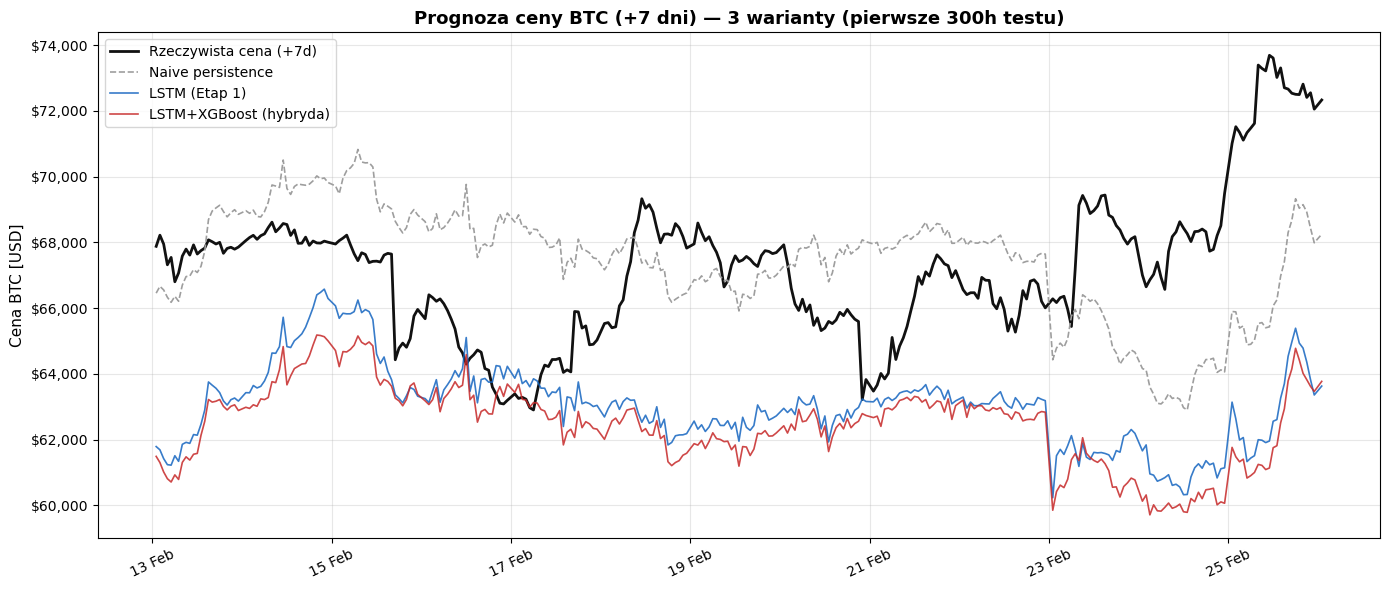

In [13]:
test_dates = test_df.index[WINDOW_LSTM:]
n_show = min(300, len(test_dates))

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(test_dates[:n_show], test_price_true[:n_show], color=COLOR_TRUE, lw=2.0, label='Rzeczywista cena (+7d)')
ax.plot(test_dates[:n_show], pred_price_naive[:n_show], color=COLOR_NAIVE, lw=1.2, ls='--', label='Naive persistence')
ax.plot(test_dates[:n_show], pred_price_lstm[:n_show], color=COLOR_LSTM, lw=1.2, alpha=0.85, label='LSTM (Etap 1)')
ax.plot(test_dates[:n_show], pred_price_hybrid[:n_show], color=COLOR_HYBRID, lw=1.2, alpha=0.85, label='LSTM+XGBoost (hybryda)')
ax.set_title(f'Prognoza ceny BTC (+7 dni) — 3 warianty (pierwsze {n_show}h testu)', fontweight='bold')
ax.set_ylabel('Cena BTC [USD]')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'hybrid7d_predictions.png'), bbox_inches='tight', dpi=130)
plt.show()

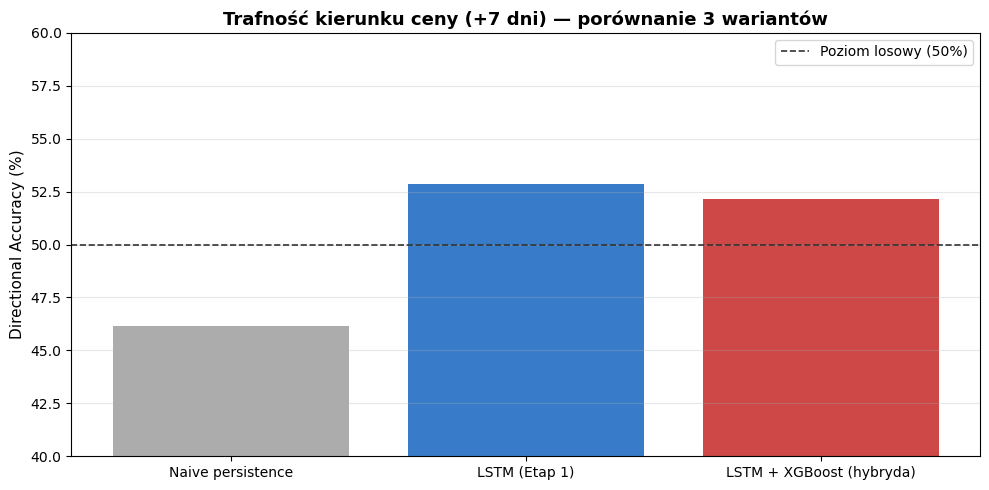

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(results_df['Model'], results_df['DA (%)'], color=[COLOR_NAIVE, COLOR_LSTM, COLOR_HYBRID], alpha=0.85)
ax.axhline(50, color='#333', lw=1.2, ls='--', label='Poziom losowy (50%)')
ax.set_ylabel('Directional Accuracy (%)')
ax.set_title('Trafność kierunku ceny (+7 dni) — porównanie 3 wariantów', fontweight='bold')
ax.set_ylim(40, max(60, results_df['DA (%)'].max() + 3))
ax.legend()
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'hybrid7d_da_comparison.png'), bbox_inches='tight', dpi=130)
plt.show()

## 12. Jak interpretować wynik

- **Test istotności w sekcji 10b** to najważniejsza liczba — jeśli DA hybrydy/LSTM jest
  poniżej ~2 odchyleń std. od 50%, to nie jest statystycznie odróżnialne od losowości,
  niezależnie jak "ładnie" wygląda w tabeli.
- **Diagnostyka mode collapse** (górna część sekcji 10b) — jeśli `% predykcji > 0` jest
  bliskie 100% lub 0%, model znowu znalazł "łatwe" rozwiązanie zamiast uczyć się realnej
  zależności, i wynik DA jest artefaktem rozkładu klas w teście, nie umiejętności.
- **Jeśli DA jest teraz wyraźnie wyższe niż przy +1h/+24h** (i przechodzi test istotności) —
  to potwierdza hipotezę z artykułu o rosnącym sygnale wraz z horyzontem, i uzasadnia dalszą
  inwestycję w to (np. dodanie zmiennych makro z FRED, których jeszcze nie mamy).
- **Jeśli DA nadal jest w okolicach poziomu losowego** — to mocny dowód, że sam dłuższy
  horyzont na *tym samym* zestawie cech (whale/opcje/techniczne) nie wystarcza, i faktycznie
  potrzebne są nowe, jakościowo inne źródła danych (makroekonomiczne) — zgodnie z tym co
  było kluczowe w pracy referencyjnej.

---
*Projekt: Bitcoin On-Chain Analysis — wersja godzinowa | Hybryda LSTM+XGBoost, horyzont +7 dni*

WYNIKI SYMULACJI INWESTYCYJNEJ (Kapitał początkowy: $10,000 | Prowizja: 0.05%)
                                 Strategia Kapitał końcowy ($) Zwrot (%) Max Drawdown (%) Sharpe Ratio Win Rate (%) Transakcje
                Buy & Hold (BTC Benchmark)           $9,611.44    -3.89%          -29.36%         0.02       50.03%          1
                         LSTM — Long/Short          $11,708.83   +17.09%          -15.53%         1.07       50.14%         84
            LSTM — Long Only (Kup/Gotówka)          $10,911.01    +9.11%          -10.80%         0.91       50.25%         83
             Hybryda LSTM+XGB — Long/Short          $12,227.01   +22.27%          -15.53%         1.30       50.31%         95
Hybryda LSTM+XGB — Long Only (Kup/Gotówka)          $11,198.88   +11.99%           -8.18%         1.30       50.66%         94


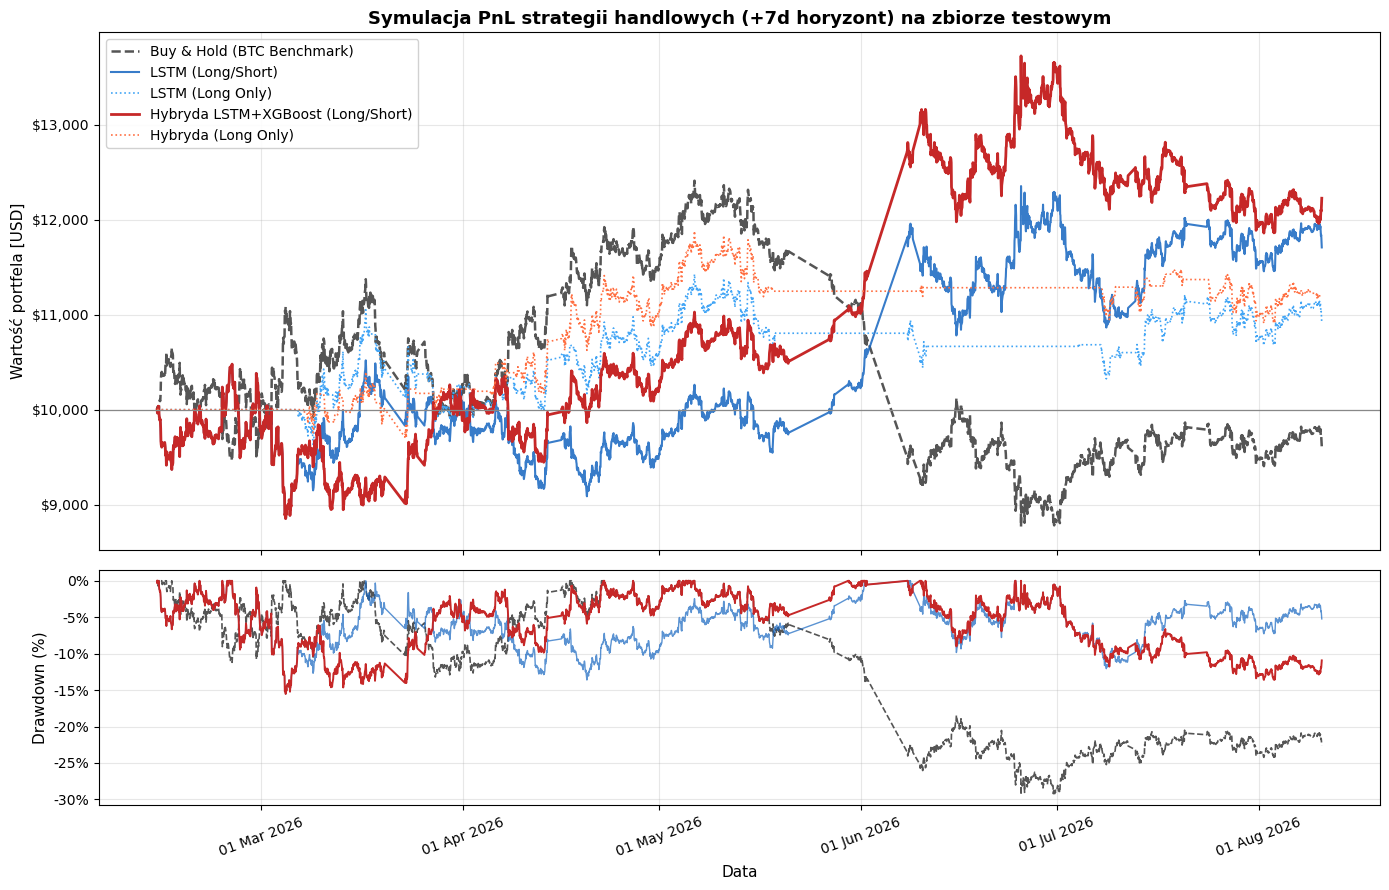

In [15]:
## 13. Symulacja strategii handlowej (Backtest PnL & Equity Curve)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os

# --- Parametry symulacji ---
INITIAL_CAPITAL = 10_000.0  # Kapitał początkowy w USD
FEE_RATE = 0.0005           # Prowizja transakcyjna: 0.05% za wejście/odwrócenie pozycji

prices = test_last_close
hourly_returns = (prices[1:] - prices[:-1]) / prices[:-1]
n_steps = len(hourly_returns)

def run_backtest(pred_returns, mode='long_short', fee=FEE_RATE):
    """
    mode: 'long_short' (1 dla wzrostu, -1 dla spadku) lub 'long_only' (1 dla wzrostu, 0 gotówka)
    """
    preds = pred_returns[:-1]
    
    if mode == 'long_short':
        positions = np.where(preds > 0, 1.0, -1.0)
    elif mode == 'long_only':
        positions = np.where(preds > 0, 1.0, 0.0)
    else:
        positions = np.ones(n_steps)  # Buy & Hold
        
    # Wyliczanie zmian pozycji do naliczenia prowizji
    pos_changes = np.abs(np.diff(np.concatenate([[0.0], positions])))
    fees = pos_changes * fee
    
    # Zwrot strategii w każdej godzinie
    strat_returns = (positions * hourly_returns) - fees
    
    # Krzywa kapitału (Equity Curve)
    equity = INITIAL_CAPITAL * np.cumprod(1.0 + strat_returns)
    equity_curve = np.concatenate([[INITIAL_CAPITAL], equity])
    
    # Metryki
    total_return = ((equity_curve[-1] - INITIAL_CAPITAL) / INITIAL_CAPITAL) * 100.0
    
    # Max Drawdown (Maksymalne obsunięcie kapitału)
    peaks = np.maximum.accumulate(equity_curve)
    drawdowns = (equity_curve - peaks) / peaks * 100.0
    max_drawdown = np.min(drawdowns)
    
    # Annualized Sharpe Ratio (roczny wskaźnik Sharpe'a przy stopie wolnej od ryzyka 0%)
    if np.std(strat_returns) > 0:
        sharpe_ratio = (np.mean(strat_returns) / np.std(strat_returns)) * np.sqrt(24 * 365)
    else:
        sharpe_ratio = 0.0
        
    # Liczba transakcji i Win Rate (odsetek zyskownych okresów z aktywną pozycją)
    active_mask = positions != 0
    win_rate = (np.mean(strat_returns[active_mask] > 0) * 100.0) if np.sum(active_mask) > 0 else 0.0
    trades_count = int(np.sum(pos_changes > 0))
    
    return {
        'equity_curve': equity_curve,
        'final_equity': equity_curve[-1],
        'total_return': total_return,
        'max_drawdown': max_drawdown,
        'sharpe_ratio': sharpe_ratio,
        'win_rate': win_rate,
        'trades_count': trades_count,
        'drawdowns': drawdowns
    }

# 1. Benchmark: Buy & Hold
bh_results = run_backtest(np.zeros(len(test_last_close)), mode='buy_hold', fee=FEE_RATE)

# 2. LSTM (Etap 1)
lstm_ls = run_backtest(pred_return_full_lstm, mode='long_short', fee=FEE_RATE)
lstm_lo = run_backtest(pred_return_full_lstm, mode='long_only', fee=FEE_RATE)

# 3. Hybryda LSTM + XGBoost (Etap 2)
hybrid_ls = run_backtest(pred_return_full_hybrid, mode='long_short', fee=FEE_RATE)
hybrid_lo = run_backtest(pred_return_full_hybrid, mode='long_only', fee=FEE_RATE)

# --- Podsumowanie w tabeli ---
sim_summary = pd.DataFrame([
    {
        'Strategia': 'Buy & Hold (BTC Benchmark)',
        'Kapitał końcowy ($)': bh_results['final_equity'],
        'Zwrot (%)': bh_results['total_return'],
        'Max Drawdown (%)': bh_results['max_drawdown'],
        'Sharpe Ratio': bh_results['sharpe_ratio'],
        'Win Rate (%)': bh_results['win_rate'],
        'Transakcje': bh_results['trades_count']
    },
    {
        'Strategia': 'LSTM — Long/Short',
        'Kapitał końcowy ($)': lstm_ls['final_equity'],
        'Zwrot (%)': lstm_ls['total_return'],
        'Max Drawdown (%)': lstm_ls['max_drawdown'],
        'Sharpe Ratio': lstm_ls['sharpe_ratio'],
        'Win Rate (%)': lstm_ls['win_rate'],
        'Transakcje': lstm_ls['trades_count']
    },
    {
        'Strategia': 'LSTM — Long Only (Kup/Gotówka)',
        'Kapitał końcowy ($)': lstm_lo['final_equity'],
        'Zwrot (%)': lstm_lo['total_return'],
        'Max Drawdown (%)': lstm_lo['max_drawdown'],
        'Sharpe Ratio': lstm_lo['sharpe_ratio'],
        'Win Rate (%)': lstm_lo['win_rate'],
        'Transakcje': lstm_lo['trades_count']
    },
    {
        'Strategia': 'Hybryda LSTM+XGB — Long/Short',
        'Kapitał końcowy ($)': hybrid_ls['final_equity'],
        'Zwrot (%)': hybrid_ls['total_return'],
        'Max Drawdown (%)': hybrid_ls['max_drawdown'],
        'Sharpe Ratio': hybrid_ls['sharpe_ratio'],
        'Win Rate (%)': hybrid_ls['win_rate'],
        'Transakcje': hybrid_ls['trades_count']
    },
    {
        'Strategia': 'Hybryda LSTM+XGB — Long Only (Kup/Gotówka)',
        'Kapitał końcowy ($)': hybrid_lo['final_equity'],
        'Zwrot (%)': hybrid_lo['total_return'],
        'Max Drawdown (%)': hybrid_lo['max_drawdown'],
        'Sharpe Ratio': hybrid_lo['sharpe_ratio'],
        'Win Rate (%)': hybrid_lo['win_rate'],
        'Transakcje': hybrid_lo['trades_count']
    }
])

print('=' * 85)
print(f'WYNIKI SYMULACJI INWESTYCYJNEJ (Kapitał początkowy: ${INITIAL_CAPITAL:,.0f} | Prowizja: {FEE_RATE*100:.2f}%)')
print('=' * 85)
print(sim_summary.to_string(index=False, formatters={
    'Kapitał końcowy ($)': '${:,.2f}'.format,
    'Zwrot (%)': '{:+.2f}%'.format,
    'Max Drawdown (%)': '{:.2f}%'.format,
    'Sharpe Ratio': '{:.2f}'.format,
    'Win Rate (%)': '{:.2f}%'.format,
    'Transakcje': '{:d}'.format
}))
print('=' * 85)

# --- Wykresy: Krzywa Kapitału oraz Obsunięcie (Drawdown) ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), sharex=True, gridspec_kw={'height_ratios': [2.2, 1]})

# Wykres 1: Kapitał w czasie
ax1.plot(test_dates, bh_results['equity_curve'], color='#555555', lw=1.8, ls='--', label='Buy & Hold (BTC Benchmark)')
ax1.plot(test_dates, lstm_ls['equity_curve'], color='#1565C0', lw=1.5, alpha=0.85, label='LSTM (Long/Short)')
ax1.plot(test_dates, lstm_lo['equity_curve'], color='#42A5F5', lw=1.2, ls=':', label='LSTM (Long Only)')
ax1.plot(test_dates, hybrid_ls['equity_curve'], color='#C62828', lw=2.0, label='Hybryda LSTM+XGBoost (Long/Short)')
ax1.plot(test_dates, hybrid_lo['equity_curve'], color='#FF7043', lw=1.2, ls=':', label='Hybryda (Long Only)')

ax1.axhline(INITIAL_CAPITAL, color='#888888', lw=0.9, ls='-')
ax1.set_title(f'Symulacja PnL strategii handlowych (+7d horyzont) na zbiorze testowym', fontweight='bold')
ax1.set_ylabel('Wartość portfela [USD]')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
ax1.legend(loc='upper left', framealpha=0.9)
ax1.grid(True, alpha=0.3)

# Wykres 2: Obsunięcie kapitału (Drawdown)
ax2.plot(test_dates, bh_results['drawdowns'], color='#555555', lw=1.2, ls='--', label='Buy & Hold DD')
ax2.plot(test_dates, lstm_ls['drawdowns'], color='#1565C0', lw=1.0, alpha=0.7, label='LSTM DD')
ax2.plot(test_dates, hybrid_ls['drawdowns'], color='#C62828', lw=1.4, label='Hybryda DD')
ax2.set_ylabel('Drawdown (%)')
ax2.set_xlabel('Data')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.0f}%'))
ax2.grid(True, alpha=0.3)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %Y'))
ax2.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'trading_strategy_backtest.png'), bbox_inches='tight', dpi=130)
plt.show()